# 1. Random Forest - Ensemble Baseado em Árvores

## Descrição
Random Forest é um método de ensemble que constrói múltiplas árvores de decisão durante o treinamento e retorna a classe que é a moda das classes preditas pelas árvores individuais. É um modelo robusto, eficiente e serve como baseline importante para comparação.

## Características
- Ensemble de árvores de decisão
- Reduz overfitting através de bagging
- Fornece importância de características
- Paralelizável
- Baseline do trabalho original

## Referências
- Breiman, L. (2001). Random Forests. Machine Learning, 45(1), 5-32.

## 1. Importações e Configurações

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os
from pathlib import Path

# Paths agnósticos
def get_project_root():
    path = Path.cwd()
    for _ in range(6):
        if (path / 'dados' / 'data_treino.csv').exists() or (path / 'data_treino.csv').exists(): return path
        if (path / 'dados' / 'processados').is_dir(): return path
        path = path.parent
    return Path.cwd()
PROJECT_ROOT = get_project_root()
DIR_DADOS_PROCESSADOS = PROJECT_ROOT / 'dados' / 'processados'
DIR_MODELOS = PROJECT_ROOT / 'modelos'
DIR_GRAFICOS = PROJECT_ROOT / 'graficos'

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, f1_score, accuracy_score,
    precision_score, recall_score, auc
)
import joblib

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

os.makedirs(DIR_GRAFICOS, exist_ok=True)
os.makedirs(DIR_MODELOS, exist_ok=True)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2. Carregamento dos Dados Pré-processados

In [14]:
# Carregar datasets pré-processados
with open(DIR_DADOS_PROCESSADOS / 'datasets.pkl', 'rb') as f:
    datasets = pickle.load(f)

# Usar dataset baseline
X_train = datasets['baseline']['X_train']
X_val = datasets['baseline']['X_val']
X_test = datasets['baseline']['X_test']
y_train = datasets['baseline']['y_train']
y_val = datasets['baseline']['y_val']
y_test = datasets['baseline']['y_test']

print(f"Dataset carregado: {datasets['baseline']['descricao']}")
print(f"\nDimensões:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val: {X_val.shape}")
print(f"  X_test: {X_test.shape}")
print(f"\nDistribuição de classes (treino): {y_train.value_counts().to_dict()}")

Dataset carregado: Mediana + StandardScaler + SelectKBest

Dimensões:
  X_train: (1730, 50)
  X_val: (372, 50)
  X_test: (372, 50)

Distribuição de classes (treino): {1: 952, 0: 778}


## 3. Otimização de Hiperparâmetros com Random Search

In [15]:
# Definir espaço de hiperparâmetros para Random Search
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
    'class_weight': ['balanced', None]
}

# Random Search com validação cruzada
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    rf_base,
    param_dist,
    n_iter=50,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Iniciando Random Search...")
random_search.fit(X_train, y_train)

print(f"\nMelhores hiperparâmetros encontrados:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nMelhor F1-score (validação cruzada): {random_search.best_score_:.4f}")

Iniciando Random Search...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Melhores hiperparâmetros encontrados:
  n_estimators: 300
  min_samples_split: 2
  min_samples_leaf: 4
  max_features: log2
  max_depth: 20
  class_weight: None
  bootstrap: True

Melhor F1-score (validação cruzada): 0.7089


## 4. Treinamento do Modelo Otimizado

In [16]:
# Treinar modelo com melhores hiperparâmetros
rf_model = random_search.best_estimator_

# Avaliar no conjunto de validação
y_val_pred = rf_model.predict(X_val)
y_val_pred_proba = rf_model.predict_proba(X_val)[:, 1]

# Avaliar no conjunto de teste
y_test_pred = rf_model.predict(X_test)
y_test_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


## 5. Avaliação do Modelo

In [17]:
# Calcular métricas no conjunto de validação
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_roc_auc = roc_auc_score(y_val, y_val_pred_proba)

# Calcular métricas no conjunto de teste
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)

# Calcular Precision-Recall AUC
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_test_pred_proba)
test_pr_auc = auc(recall_vals, precision_vals)

print("="*70)
print("MÉTRICAS DE DESEMPENHO - RANDOM FOREST")
print("="*70)
print(f"\nCONJUNTO DE VALIDAÇÃO:")
print(f"  Acurácia: {val_accuracy:.4f}")
print(f"  Precisão: {val_precision:.4f}")
print(f"  Recall: {val_recall:.4f}")
print(f"  F1-Score: {val_f1:.4f}")
print(f"  ROC-AUC: {val_roc_auc:.4f}")

print(f"\nCONJUNTO DE TESTE:")
print(f"  Acurácia: {test_accuracy:.4f}")
print(f"  Precisão: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1-Score: {test_f1:.4f}")
print(f"  ROC-AUC: {test_roc_auc:.4f}")
print(f"  Precision-Recall AUC: {test_pr_auc:.4f}")
print("="*70)

MÉTRICAS DE DESEMPENHO - RANDOM FOREST

CONJUNTO DE VALIDAÇÃO:
  Acurácia: 0.6183
  Precisão: 0.6340
  Recall: 0.7268
  F1-Score: 0.6773
  ROC-AUC: 0.6937

CONJUNTO DE TESTE:
  Acurácia: 0.6371
  Precisão: 0.6367
  Recall: 0.7951
  F1-Score: 0.7072
  ROC-AUC: 0.7034
  Precision-Recall AUC: 0.7333


In [18]:
# Relatório de classificação detalhado
print("\nRELATÓRIO DE CLASSIFICAÇÃO (Conjunto de Teste):")
print(classification_report(y_test, y_test_pred, target_names=['Não-Supercondutor', 'Supercondutor']))


RELATÓRIO DE CLASSIFICAÇÃO (Conjunto de Teste):
                   precision    recall  f1-score   support

Não-Supercondutor       0.64      0.44      0.52       167
    Supercondutor       0.64      0.80      0.71       205

         accuracy                           0.64       372
        macro avg       0.64      0.62      0.62       372
     weighted avg       0.64      0.64      0.62       372



## 6. Visualizações de Desempenho

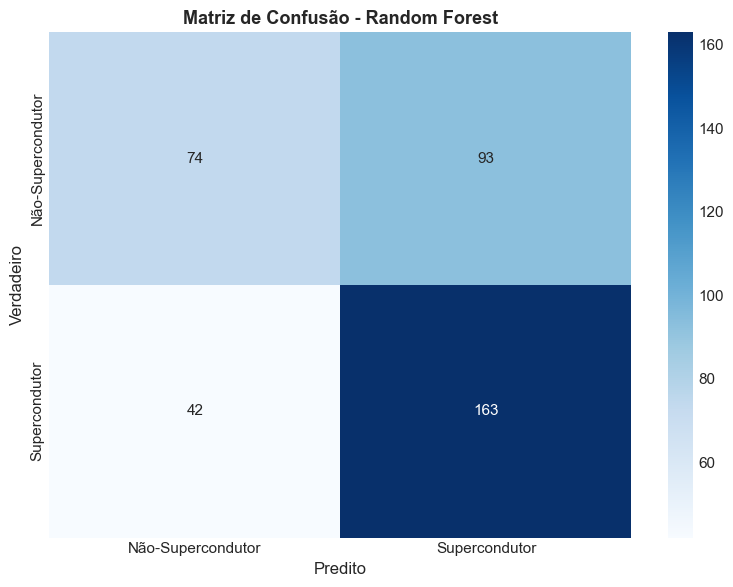

Gráfico salvo: g:\My Drive\FisicaComp\TCC\graficos\01_rf_confusion_matrix.png


In [19]:
# Matriz de Confusão
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax,
            xticklabels=['Não-Supercondutor', 'Supercondutor'],
            yticklabels=['Não-Supercondutor', 'Supercondutor'])
ax.set_ylabel('Verdadeiro', fontsize=12)
ax.set_xlabel('Predito', fontsize=12)
ax.set_title('Matriz de Confusão - Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DIR_GRAFICOS / '01_rf_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico salvo: {DIR_GRAFICOS / '01_rf_confusion_matrix.png'}")

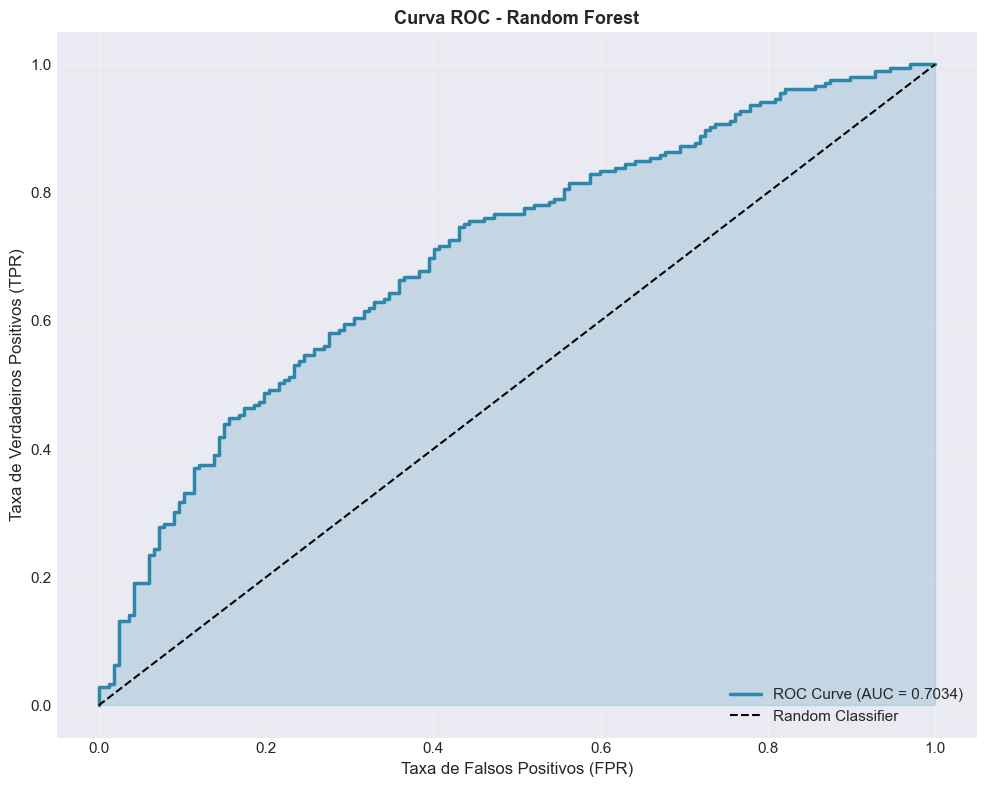

Gráfico salvo: g:\My Drive\FisicaComp\TCC\graficos\01_rf_roc_curve.png


In [20]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(fpr, tpr, label=f'ROC Curve (AUC = {test_roc_auc:.4f})', linewidth=2.5, color='#2E86AB')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.2, color='#2E86AB')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
ax.set_title('Curva ROC - Random Forest', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DIR_GRAFICOS / '01_rf_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico salvo: {DIR_GRAFICOS / '01_rf_roc_curve.png'}")

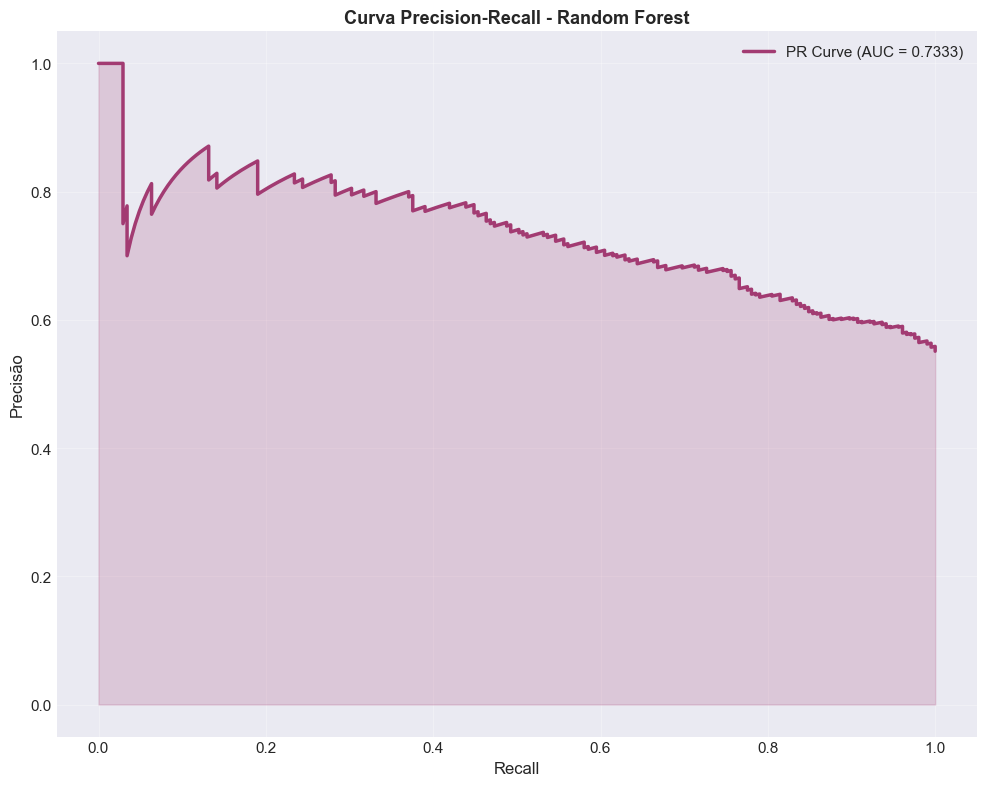

Gráfico salvo: g:\My Drive\FisicaComp\TCC\graficos\01_rf_pr_curve.png


In [21]:
# Curva Precision-Recall
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_test_pred_proba)

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(recall_vals, precision_vals, label=f'PR Curve (AUC = {test_pr_auc:.4f})', linewidth=2.5, color='#A23B72')
ax.fill_between(recall_vals, precision_vals, alpha=0.2, color='#A23B72')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precisão', fontsize=12)
ax.set_title('Curva Precision-Recall - Random Forest', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DIR_GRAFICOS / '01_rf_pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico salvo: {DIR_GRAFICOS / '01_rf_pr_curve.png'}")

## 7. Importância de Características

Top 20 Features mais importantes:
               feature  importance
26        sc_DOSs_mean    0.048372
32        sc_bands_max    0.045246
31        sc_bands_std    0.043648
30       sc_bands_mean    0.043589
28         sc_DOSs_min    0.043323
29         sc_DOSs_max    0.043204
6       fermi_line_std    0.042927
0             cell_0_0    0.037585
27         sc_DOSs_std    0.035688
48  fermi_lens_shape_1    0.034485
5      fermi_line_size    0.033313
49  fermi_line_shape_1    0.033100
4             cell_1_1    0.032570
25      recip_latt_2_2    0.032064
13        position_3_2    0.027845
10        position_2_0    0.027574
9         position_1_2    0.026190
7         position_0_2    0.025541
23      recip_latt_1_0    0.023980
8         position_1_0    0.023971


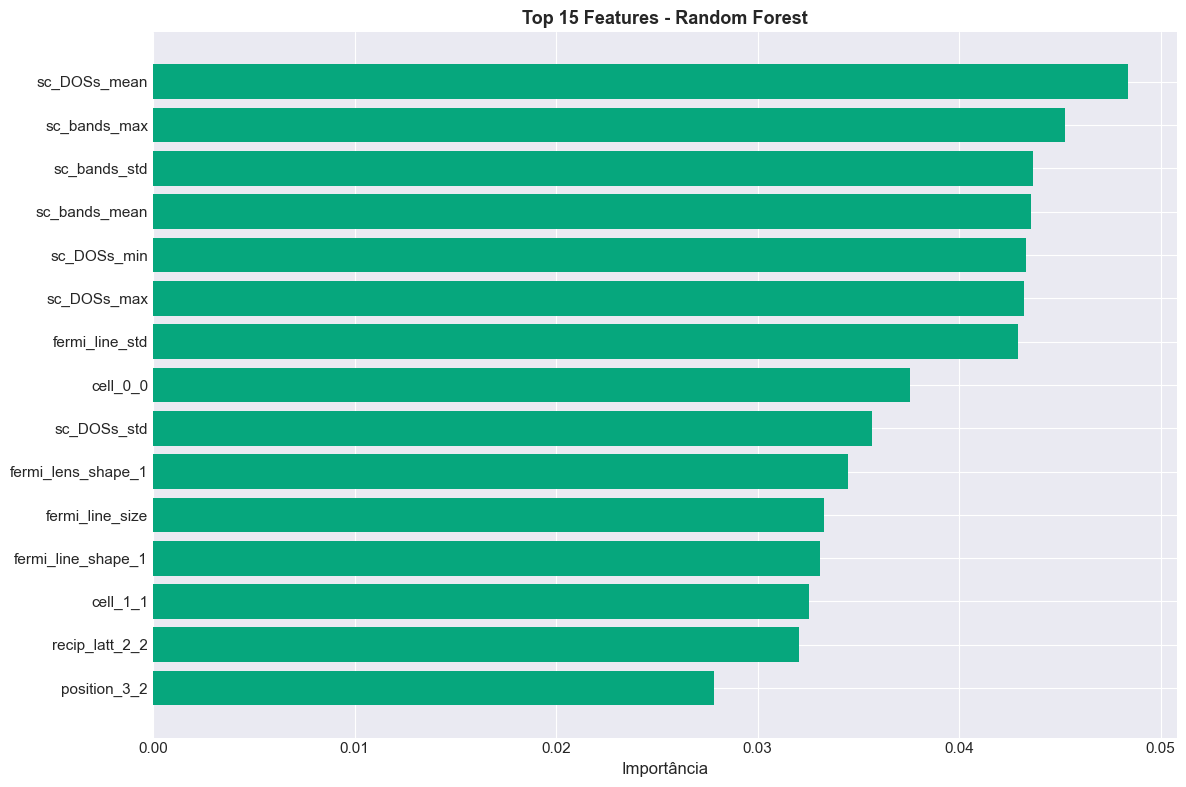


Gráfico salvo: g:\My Drive\FisicaComp\TCC\graficos\01_rf_feature_importance.png


In [22]:
# Extrair importância de características
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 Features mais importantes:")
print(feature_importance.head(20))

# Visualizar top 15 features
fig, ax = plt.subplots(figsize=(12, 8))
top_features = feature_importance.head(15)
ax.barh(range(len(top_features)), top_features['importance'].values, color='#06A77D')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values)
ax.set_xlabel('Importância', fontsize=12)
ax.set_title('Top 15 Features - Random Forest', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(DIR_GRAFICOS / '01_rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nGráfico salvo: {DIR_GRAFICOS / '01_rf_feature_importance.png'}")

## 8. Salvamento do Modelo e Resultados

In [23]:
# Salvar modelo treinado
joblib.dump(rf_model, DIR_MODELOS / 'random_forest_model.pkl')

# Salvar resultados em dicionário
results = {
    'model_name': 'Random Forest',
    'best_params': random_search.best_params_,
    'metrics': {
        'val_accuracy': val_accuracy,
        'val_precision': val_precision,
        'val_recall': val_recall,
        'val_f1': val_f1,
        'val_roc_auc': val_roc_auc,
        'test_accuracy': test_accuracy,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1,
        'test_roc_auc': test_roc_auc,
        'test_pr_auc': test_pr_auc
    },
    'feature_importance': feature_importance,
    'predictions': {
        'y_test_pred': y_test_pred,
        'y_test_pred_proba': y_test_pred_proba
    }
}

with open(DIR_MODELOS / 'random_forest_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print("Modelo e resultados salvos com sucesso!")
print(f"  - Modelo: {DIR_MODELOS / 'random_forest_model.pkl'}")
print(f"  - Resultados: {DIR_MODELOS / 'random_forest_results.pkl'}")

Modelo e resultados salvos com sucesso!
  - Modelo: g:\My Drive\FisicaComp\TCC\modelos\random_forest_model.pkl
  - Resultados: g:\My Drive\FisicaComp\TCC\modelos\random_forest_results.pkl


## 9. Conclusões e Próximas Etapas

In [24]:
print("="*70)
print("RESUMO - RANDOM FOREST")
print("="*70)
print(f"\nDesempenho no Conjunto de Teste:")
print(f"  F1-Score: {test_f1:.4f}")
print(f"  ROC-AUC: {test_roc_auc:.4f}")
print(f"  Acurácia: {test_accuracy:.4f}")
print(f"\nTop 3 Features:")
for idx, row in feature_importance.head(3).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")
print(f"\nHiperparâmetros Otimizados:")
for param, value in list(random_search.best_params_.items())[:5]:
    print(f"  {param}: {value}")
print("\n" + "="*70)
print("Próxima etapa: Treinar XGBoost")
print("="*70)

RESUMO - RANDOM FOREST

Desempenho no Conjunto de Teste:
  F1-Score: 0.7072
  ROC-AUC: 0.7034
  Acurácia: 0.6371

Top 3 Features:
  sc_DOSs_mean: 0.0484
  sc_bands_max: 0.0452
  sc_bands_std: 0.0436

Hiperparâmetros Otimizados:
  n_estimators: 300
  min_samples_split: 2
  min_samples_leaf: 4
  max_features: log2
  max_depth: 20

Próxima etapa: Treinar XGBoost
